<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>文本数据下载（1）(郑海超)</B></font></td></tr></table>

# 教学内容
- 金融文本数据及其获取方法简介
- 文本处理和数据抓取预备知识
    - 转移字符
    - 编码与解码
    - 认识Http协议
    - 网页结构
-  使用requests下载数据

- 课后学习安排

# 上次课后作业分享与讨论

- 分享
- 讨论

# 分享：How to Build Your Career in AI
- Chapter 3: Should You Learn Math to Get a Job in AI?

# 金融文本数据

## 金融文本
- 公司新闻
- CCTV新闻
- 在线评论
- 企业年报

## 使用新闻文本数据做股票分析
- Case: stock_predict


- 该案例本周仅仅用于展示，代码不展开讲解。
- 课程后续内容会涵盖该案例。

## 使用股吧评论做金融情感分析
- Sanjiv R. Das, Mike Y. Chen, (2007) Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management Science 53(9):1375-1388.

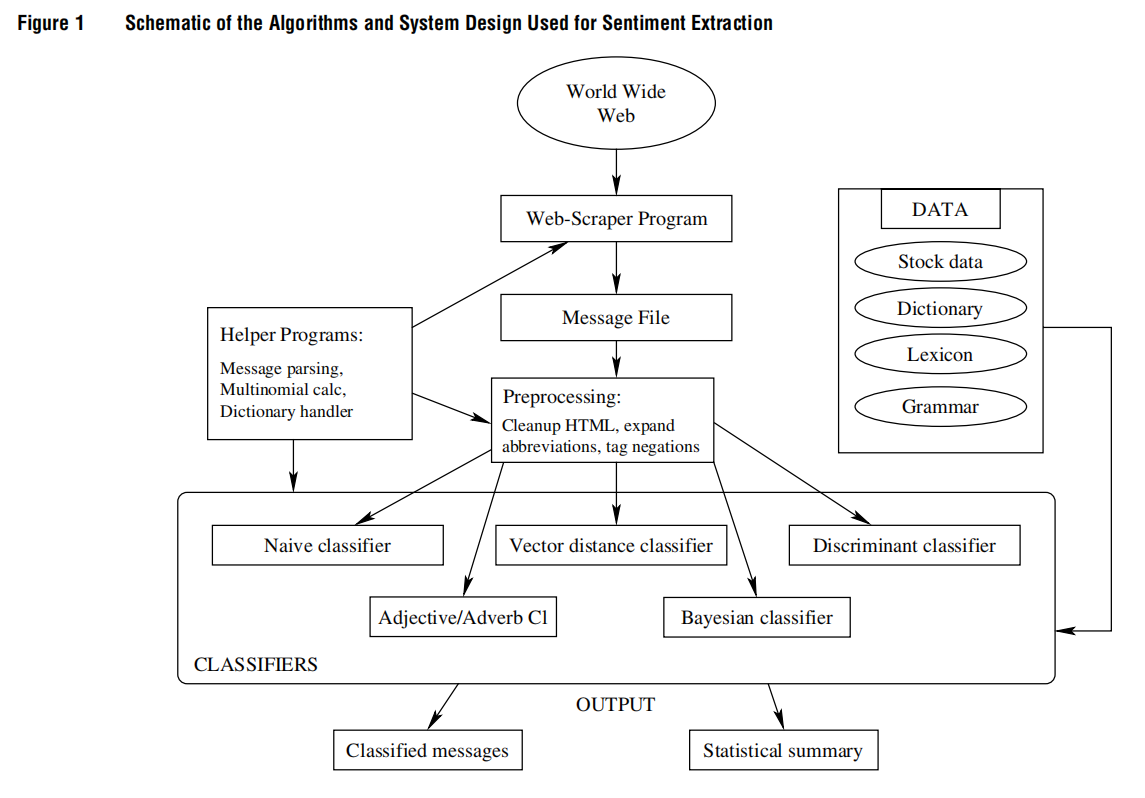

# 获取金融文本的方法
- 使用第三方整理的数据库：财经数据库、API（一般需要申请付费），例如tushare, arkshare等
- 动手抓取数据：爬虫（更通用）

# 使用API获取金融文本举例
- arkshare
- tushare(大家自行探索)


## 使用arkshare获取公司新闻数据

[arkshare](https://akshare.akfamily.xyz/introduction.html)

pip install akshare  -i https://pypi.tuna.tsinghua.edu.cn/simple


In [ ]:
! pip install akshare -i https://mirrors.aliyun.com/pypi/simple/

In [13]:
import akshare as ak

In [ ]:
# 平安银行
symbol = "000001.SZ"

In [ ]:
stock_news_em_df = ak.stock_news_em(symbol=symbol)
stock_news_em_df

## 使用arkshare获取CCTV数据

[arkshare CCTV news](https://akshare.akfamily.xyz/data/others/others.html#id9)

In [15]:
import akshare as ak

news_cctv_df = ak.news_cctv(date="20250906")
print(news_cctv_df)

        date                                              title  \
0   20250906                       习近平向中俄友好、和平与发展委员会第十五次双方全会致贺辞   
1   20250906  伟大胜利彪炳史册 凝心聚力再启新程——习近平总书记在纪念中国人民抗日战争暨世界反法西斯战争胜...   
2   20250906  人民日报评论员文章：坚持走和平发展道路——论学习贯彻习近平总书记在纪念中国人民抗日战争暨世界...   
3   20250906              总台直播全景呈现纪念中国人民抗日战争暨世界反法西斯战争胜利80周年大会盛况   
4   20250906                                  中国零售业景气指数创8个月以来新高   
5   20250906                           今年前七个月我国轻工业稳健运行 营收超13万亿元   
6   20250906                                各粮食主产区加强田管 力保秋粮稳产增收   
7   20250906                         “十四五”时期综保区等对外开放平台成为外贸增长新高地   
8   20250906                               “十四五”期间全国水生态环境质量持续向好   
9   20250906                          今年前七个月广东新设外资企业数量同比增长32.7%   
10  20250906                            【活力中国调研行】重庆：汽车产业链上的绿色跃升   
11  20250906                                             国内联播快讯   
12  20250906  守护历史记忆 推动世界和平发展——国际社会积极评价习近平主席在纪念中国人民抗日战争暨世界反法...   
13  20250906                            联合国大会高票通过联合国同上海合作组织合作决

# 爬虫和文本相关的基础知识
- 字符串与转义字符
- 字符的编码与解码
- Http协议
- 网页的结构
- 网页的解析 (正则表达式、BeautifulSoup)等

## Escape character

[转义字符](https://ai4science.feishu.cn/wiki/Bnpow6FsziP9v5kxWz7cwmQNnEc)

python的转义字符是\，可以转义很多字符，比如
- \n表示换行，
- \t表示制表符，
- 字符\本身也要转义

Python还允许用“r”表示内部的字符串默认不转义。

下面的字符串有什么区别？

```python
path = "c:\towhere"
path = r"c:\towhere"
path = "c:\nowhere.py"
p = 'c:\\nowhere.py'
```

In [18]:
print(r'c:\\nowhere.py')

c:\\nowhere.py


转义字符还可以用来在字符串中嵌入特定编码的字符




          
"\x48" 是一个十六进制转义序列

具体来说：
- `\x` 是十六进制转义的前缀
- `48` 是十六进制数值，对应的十进制是 72
- 十进制 72 对应的 ASCII 字符是大写字母 'H'

所以在字符串中，"\x48" 就等同于字符 'H'。例如，在 Python 中执行 `print("\x48ello")` 会输出 `Hello`。
        

In [20]:
# 转义字符还可以用来在字符串中嵌入特定编码的字符
print("\x48ello")

Hello


## 编码与解码：encode and decode

### ASCII编码

**ASCII** stands for American Standard Code for Information Interchange. Computers can only understand numbers, so an ASCII code is the numerical representation of a character such as 'a' or '0' or an action of some sort.

<img src="../img/ascii.png" align='left' width = 1500 height = 800/>

         
`0x61` 和 `"\x61"相同吗？

- `0x61` 是**十六进制整数**表示形式，在Python中表示十进制的97。在ASCII编码表中，数字97对应的字符是小写字母'a'。
- `"\x61"` 是**字符串**，其中包含一个**十六进制转义序列**。在字符串中，`\x` 后跟两位十六进制数表示一个ASCII字符，所以 `"\x61"` 实际上是包含单个字符'a'的字符串。


可以通过以下代码验证：
```python
print(0x61)        # 输出: 97
print("\x61")     # 输出: a
print(chr(0x61))   # 输出: a (将整数转换为对应的字符)
print(ord('a'))    # 输出: 97 (将字符转换为对应的ASCII码)
hex(97) # 十进制-》十六进制

```
ord是Python 的内置函数，其主要作用是 返回单个字符对应的 Unicode **码点**（或 ASCII 码） 。        

"0x61" 是一个十六进制数的表示形式，在编程和计算机系统中有特定含义：

1. **前缀含义**：`0x` 是编程中表示十六进制数的标准前缀
2. **数值转换**：`61` 作为十六进制数值，转换为十进制是：
   - 6×16¹ + 1×16⁰ = 96 + 1 = 97     

**猜测chr(0x63)是那个字符？**

### unicode

Today’s programs need to be able to handle **a wide variety of characters**. Applications are often internationalized to display messages and output in a variety of user-selectable languages; the same program might need to output an error message in English, French, Japanese, Hebrew, or Russian.

Get more informaiton about [unicode](https://docs.python.org/3/howto/unicode.html)

Unicode (https://www.unicode.org/) is a specification that aims to list every character used by human languages and give each character its own unique code.

The Unicode standard describes how characters are represented by code points.

[unicode](https://unicode.org/charts/)

[chess](https://unicode.org/charts/PDF/U2600.pdf)

[emotions](https://unicode.org/charts/PDF/U1F600.pdf)

<img src="../img/unicode.png" align='left' width = 400 height = 400/>

Strictly, these definitions imply that it’s meaningless to say ‘this is character U+265E’. **U+265E is a code point, which represents some particular character**; in this case, it represents the character ‘BLACK CHESS KNIGHT’, ‘♞’. In informal contexts, this distinction between code points and characters will sometimes be forgotten.





- codeID
- value 
- name

Unicode码点是一个用于唯一标识Unicode标准中每个字符的数值，范围从 U+0000 到 U+10FFFF （十六进制表示）。
- 0x1F602
- 0x1F625

```python
chr(0x1F602)
ord('😂')
hex(ord('😂'))

emoji = '😒'
code_point = ord(emoji)
char_from_code = chr(code_point)
```

In [21]:
chr(0x1F602)

'😂'

Unicode字符占用的字节数取决于所使用的编码方案，没有固定统一的答案。在实际应用中，UTF-8因其空间效率和兼容性成为最广泛使用的编码方案。

In [ ]:
# 定义Unicode字符
emoji = '😂'   #等同于 chr(0x1F602)

# 转换为UTF-8编码的字节序列
utf8_bytes = emoji.encode('utf-8')

# 以十六进制格式打印结果
print(f"UTF-8编码（字节表示）: {utf8_bytes}") 

        
这段代码展示了Unicode字符与UTF-8编码之间的转换过程，下面是详细解释：

**1. 定义Unicode字符**
```python
emoji = '😂'   #等同于 chr(0x1F602)
```
- `'😂'` 是一个emoji表情符号（笑哭表情）
- `0x1F602`是一个十六进制数，表示Unicode码点U+1F602

**2. 转换为UTF-8编码的字节序列**
```python
utf8_bytes = emoji.encode('utf-8')
```
- `.encode('utf-8')` 方法将Unicode字符转换为UTF-8编码的字节序列
- UTF-8是一种变长编码方案，用于在计算机中存储和传输Unicode字符
- 对于码点在U+0000到U+007F之间的字符，UTF-8用1个字节表示
- 对于码点在U+0080到U+FFFF之间的字符，UTF-8用2-3个字节表示
- 对于码点在U+10000到U+10FFFF之间的字符（如这个emoji），UTF-8用4个字节表示

**3. 以十六进制格式打印结果**
```python
print(f"UTF-8编码（字节表示）: {utf8_bytes}")        # 输出: b'\xf0\x9f\x98\x92'
```
- 这行代码打印UTF-8编码后的字节序列
- 输出 `b'\xf0\x9f\x98\x82'` 表示：
  - 这是一个字节对象（以`b`开头）
  - 由4个字节组成，每个字节用十六进制表示
  - 这4个字节 `0xF0`, `0x9F`, `0x98`, `0x82` 是Unicode码点U+1F602的UTF-8编码结果        

### unicodedata

In [ ]:
import unicodedata

emoji = '😒'

emoji_name = unicodedata.name(emoji)
emoji_name

In [ ]:
name = unicodedata.name("😂")
value = unicodedata.lookup(name)
name

In [ ]:
# then we can lookup its value and print it
name = unicodedata.name("财")
print(name)
value = unicodedata.lookup(name)

###  Unicode**字符串转**和字节对象（bytes object）

**字节对象（bytes object）是什么**？

字节对象是 Python 中的一种基本数据类型，它用于在计算机中表示和操作二进制数据 。在 Python 中，字节对象以 b 前缀标记，如 b'Hello, World!' 。

字节对象的特点：

1. 存储原始二进制数据 ：字节对象直接存储计算机能理解的原始二进制数据（0和1组成的序列）
2. bytes 对象本质上是 0-255范围内整数的有序集合 ，其中每个整数代表一个字节（8位二进制数）。

用途：
- 网络传输协议（如HTTP、TCP/IP）通常以二进制格式传输数据
- 当以二进制模式（ 'rb' 或 'wb' ）读写文件时，Python使用字节对象（例如图片数据）
- 通过 encode() 和 decode() 方法，可以在Unicode字符串和字节表示之间进行转换

type(b'H')  # 输出: <class 'bytes'>

type(72)    # 输出: <class 'int'>

b'Hell0'[0]     # 输出: 72 (这是一个整数)

b'H' == 72  # 输出: False (类型不同)


bytes 和 str （字符串）是Python中处理数据的两种基本方式，它们的主要区别在于：

- str 存储的是Unicode字符，用于表示文本信息
- bytes 存储的是原始字节，用于表示二进制数据

In [ ]:
# ASCII 编码 (只能处理基本英文字符)
ascii_text = "Hello, World!"
encoded_ascii = ascii_text.encode('ascii') # 字节串（字节对象）
print(f"ASCII 编码: {encoded_ascii}")

直接打印字节对象展示的是其字符串表示形式（保留可识别的字符），而转换为列表后打印展示的是每个字节的底层数值（ASCII码）

In [ ]:
byte_string = b'Hello, World!'
# 查看每个字节的十进制ASCII值
print(list(encoded_ascii))

In [ ]:
# 查看每个字节的十六进制表示
print([hex(b) for b in byte_string])  # 输出十六进制列表

0x48 = 4×16¹ + 8×16⁰ = 4×16 + 8×1 = 64 + 8 = 72

In [ ]:
# 解码
decoded_ascii = encoded_ascii.decode('ascii')
print(decoded_ascii)


大家观察分析下面的代码和输出

In [ ]:
text_cn = "I love 西财"
try:
    text_cn.encode("ascii")  # ASCII 无法编码中文
except UnicodeEncodeError as e:
    print(f"编码失败: {e}")

In [ ]:
text = "你好，世界!"
# 字符串转字节（编码）
utf8_bytes = text.encode('utf-8')  # b'\xe4\xbd\xa0\xe5\xa5\xbd\xef\xbc\x8c\xe4\xb8\x96\xe7\x95\x8c!'
# 字节转字符串（解码）
decoded_text = utf8_bytes.decode('utf-8')  # "你好，世界!"

In [ ]:
# decoded_text
decoded_text

### encoding和decoding总结

Unicode把所有语言都统一到一套编码里(2字节），这样就不会再有乱码问题了。但是，用Unicode编码比ASCII编码需要更多的存储空间，在存储和传输上就十分不划算。又出现了把Unicode编码转化为“可变长编码”的UTF-8编码。更多资料可以参考[字符编码](https://www.liaoxuefeng.com/wiki/1016959663602400/1017075323632896)。在计算机内存中，统一使用Unicode编码，当需要保存到硬盘或者需要传输的时候，就转换为其他编码：
* 将Unicode字符串编码为字节(encode)
* 将字节解码为Unicode字符串(decode)

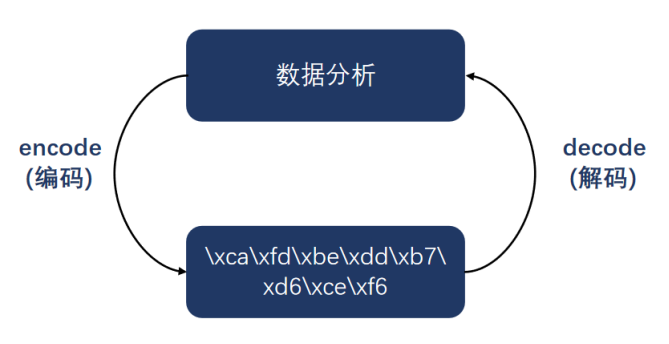

In [9]:
e = '金融数据分析与可视化'.encode('gbk')

In [10]:
e

b'\xbd\xf0\xc8\xda\xca\xfd\xbe\xdd\xb7\xd6\xce\xf6\xd3\xeb\xbf\xc9\xca\xd3\xbb\xaf'

In [11]:
e.decode('gbk')

'金融数据分析与可视化'

In [12]:
# encoding一个字符串
text = "金融数据分析与可视化"
b = text.encode("gbk")
b

b'\xbd\xf0\xc8\xda\xca\xfd\xbe\xdd\xb7\xd6\xce\xf6\xd3\xeb\xbf\xc9\xca\xd3\xbb\xaf'

In [13]:
# encodicng一个字符串
c = text.encode("utf-8")
c

b'\xe9\x87\x91\xe8\x9e\x8d\xe6\x95\xb0\xe6\x8d\xae\xe5\x88\x86\xe6\x9e\x90\xe4\xb8\x8e\xe5\x8f\xaf\xe8\xa7\x86\xe5\x8c\x96'

In [14]:
b.decode("utf-8")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xbd in position 0: invalid start byte

### chardet

字符串编码一直是令人非常头疼的问题，尤其是我们在处理一些不规范的第三方网页的时候。虽然Python提供了Unicode表示的str和bytes两种数据类型，并且可以通过encode()和decode()方法转换，但是，在不知道编码的情况下，对bytes做decode()不好做。

对于未知编码的bytes，要把它转换成str，需要先“猜测”编码。猜测的方式是先收集各种编码的特征字符，根据特征字符判断，就能有很大概率“猜对”。

当然，我们肯定不能从头自己写这个检测编码的功能，这样做费时费力。chardet这个第三方库正好就派上了用场。用它来检测编码，简单易用。

如果安装了Anaconda，chardet就已经可用了。否则，需要在命令行下通过pip安装：

pip install chardet

In [16]:
import chardet

In [17]:
data = '金融数据分析与可视化'.encode('gbk')

In [18]:
data

b'\xbd\xf0\xc8\xda\xca\xfd\xbe\xdd\xb7\xd6\xce\xf6\xd3\xeb\xbf\xc9\xca\xd3\xbb\xaf'

In [ ]:
chardet.detect(data) 

{'encoding': 'GB2312', 'confidence': 0.99, 'language': 'Chinese'}

GBK是GB2312的超集，两者在编码上兼容，但GBK支持更多的字符。

In [20]:
with open("example.txt","rb") as f:
    r = f.read()
r

b'this is used for learning \xe7\xbc\x96\xe7\xa0\x81'

In [ ]:
chardet.detect(r)

In [ ]:
r.decode("utf-8")

### exercise in class
下面代码的输出是什么？

In [15]:
comment = "继续加仓了"

b = comment.encode("utf-8")

r = b.decode("utf-8")

r

'继续加仓了'

# Http协议

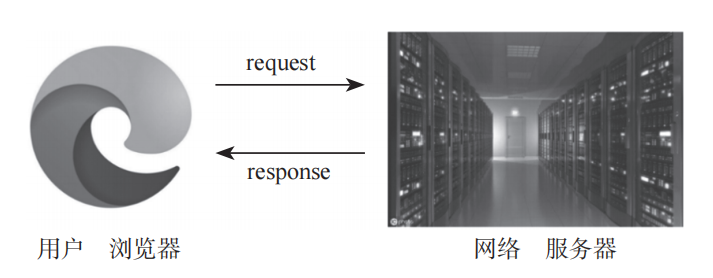

[使用浏览器体验request和response过程](https://ai4science.feishu.cn/wiki/JVDqwd36KiJbU8kZO6lcHW7inHe)

1. F12,查看网络，勾选保留日志
2. https://httpbin.org/get 或者 https://www.swufe.edu.cn/
3. header，preview，response

实验
- request
- post  

# 网页结构

## 一些简单的HTML标记

实际上，浏览器就是一个解释器，负责将各种HTML(HyperText Markup Language)标记解释并显示在浏览器中，一个最基本的网页框架如下(下面代码不是python程序，无法直接运行）:

<html>
<head>
<title >标题</title>
</head>
<body>
    网页内容
</body>
</html>

### 一些常用的HTML标记：

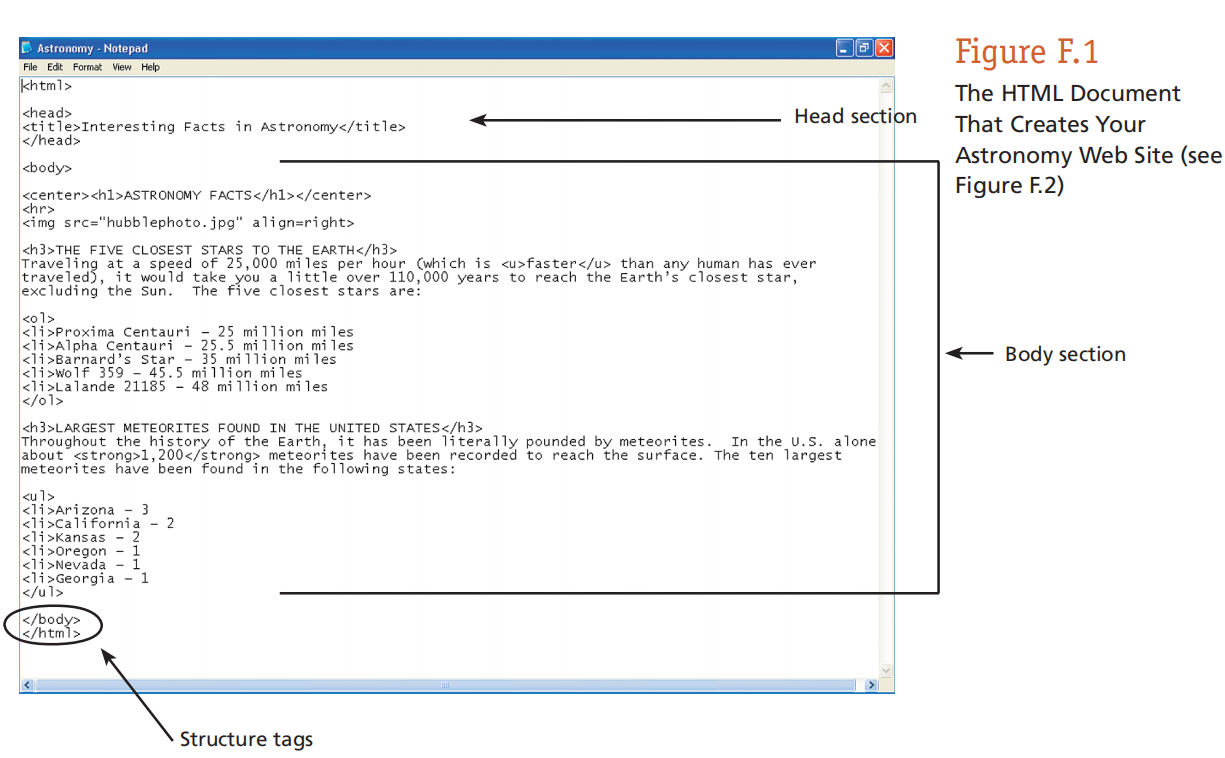

### 一些HTML标记案例

(1) 网页中插入图片：
<img src="..\img\logo.jpg">

(2) 网页中的超链接：
<A href="https://www.swufe.edu.cn/">西南财经大学</A>

(3)制作各种列表：<br>
<br>(3.1)自定义列表：<br>
<dl>
   <dt>联系人<dd>XXX
   <dt>联系地址<dd>北京市丰台区
   <dt>邮政编码<dd>100036
</dl>
<hr>
(3.2)无序列表：
<ul>
   <li>联系人：</li>xxx
   <li>联系地址：</li>成都市光华村街55号
   <li>邮政编码：</li>610000
</ul>

(3.3)有序列表：
<ol Type="i">
   <li>联系人：xxx</li>
   <li>联系地址：成都市光华村街55号</li>
   <li>邮政编码：610000</li>
</ol>


(4)制作表格：
<table width="470" border="1" align="center">
    <tr>
      <th>网页设计</th>
      <th>数据库开发</th>
      <th>程序设计</th>
   </tr>
   <tr>
     <td>Dreamweaver</td>
     <td>Access</td>
     <td>C++</td>
   </tr>
   <tr>
     <td>FrontPage</td>
     <td>SQL SERVER</td>
     <td>C#</td>
   </tr>
</table>

### 制作表单：
<form >
用户登录<br>
用户：<input  name="text"  type="text"  maxlength="18" size="15"><br>
密码：<input  name="password"  type="password"  maxlength="18" size="15" ><br>  
<input  name="submit"  type="submit"  value="登录">
</form>

(6)分节或分区：
  <h1>NEWS WEBSITE</h1> 
  <p>some text. some text. some text...</p> 
  ... 
  <div class="news"> 
    <h2>News headline 1</h2> 
    <p>some text. some text. some text...</p> 
    ... 
  </div> 
  <div class="news"> 
    <h2>News headline 2</h2> 
    <p>some text. some text. some text...</p> 
    ... 
  </div> 
  ...


# 课堂练习：尝试自己制作一个小的个人简介网页吧？

- 内容可以简单：包括超链接、图片、列表、表格
- 允许使用trae辅助
- 邀请一位同学演示

可以参考资料：building a webpage with html

改进  

要求：1. 包含超链接 参考文档 ；2.  包含我的个人图片，使用图片 ； 3. 介绍我目前主讲课程：金融数据分析与可视化，包括教学资源  介绍。4. 个人网页可以适当美观。



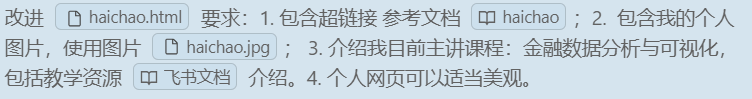

# 数据抓取爬虫

网络爬虫（又被称为网页蜘蛛，网络机器人），是一种按照一定的规则，自动地抓取万维网信息的程序或者脚本。另外一些不常使用的名字还有蚂蚁、自动索引、模拟程序或者蠕虫。

其实就是爬虫可以模拟浏览器的行为做你想做的事，**订制化**自己搜索和下载的内容，并实现自动化的操作。比如浏览器可以下载小说，但是有时候并不能批量下载，那么爬虫的功能就有用武之地了。

实现爬虫技术的编程环境有很多种，Java，Python，C++等都可以用来爬虫。其中Python很适合做爬虫，丰富的第三方库十分强大，简单几行代码便可实现你想要的功能，更重要的，Python也是数据挖掘和分析的好能手。这样爬取数据和分析数据都用Python实现！

爬虫过程：**通过对服务器发出请求得到HTML网页，然后对下载的网页进行解析，得到我们想要的内容。**

爬虫相关工具
- requests
- 网页数据解析（正则表达式、Xpath、BeautifulSoup）
- Scrapy框架

# 使用requests下载网页

To install Requests, simply run this simple command in your terminal of choice:


pip install requests

## 尝试发起请求并获取响应内容

for more data please refer to [Requests: HTTP for Humans](https://docs.python-requests.org/en/latest/index.html)

In [23]:
# Begin by importing the Requests module
import requests

In [24]:
# 上证指数股吧链接
url = "http://guba.eastmoney.com/list,zssh000001.html"

In [25]:
# Now, let’s try to get a webpage
response = requests.get(url)
response

<Response [403]>

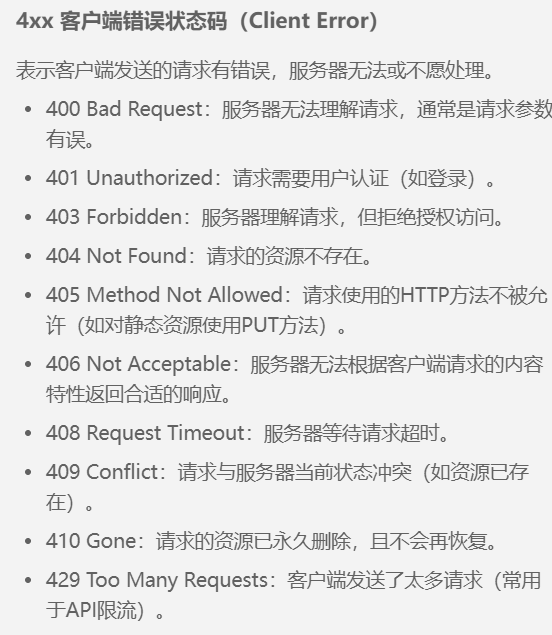

In [26]:
print(response.status_code)

403


服务器拒绝了你的访问请求,一个可能的原因是请求头中显示user agent是python程序

In [27]:
print(response.request.headers)

{'User-Agent': 'python-requests/2.32.3', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Accept': '*/*', 'Connection': 'keep-alive'}


User-Agent = python-requests/2.32.4

## 如何处理服务器拒绝请求的问题

### 添加请求头，模拟Chrome浏览器

In [32]:
import requests

url = "http://guba.eastmoney.com/list,zssh000001.html"

# 添加请求头，模拟Chrome浏览器
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}



添加请求头headers

response = requests.get(url, headers=headers)

In [33]:
# 使用带请求头的get请求
res = requests.get(url, headers=headers)

In [34]:
# 检查响应状态码
response.status_code


403

We can read the content of the server’s response.

Requests will automatically decode content from the server. Most unicode charsets are seamlessly decoded.

In [31]:
# We can read the content of the server’s response
html =  response.text
print(html)

<html>
<head><title>403 Forbidden</title></head>
<body>
<center><h1>403 Forbidden</h1></center>
<hr><center>Microsoft-IIS/10.0</center>
</body>
</html>



In [ ]:
response.content

response.text 与response.content的区别
response.text返回的是处理过的Unicode型的数据，而使用response.content返回的是bytes型的原始数据。也就是说，response.content相对于response.text来说节省了计算资源，response.content是把内容bytes返回.

而response.text是decode成Unicode.


When you make a request, Requests makes educated guesses about the encoding of the response based on the **HTTP headers**. The text encoding guessed by Requests is used when you access r.text. You can find out what encoding Requests is using, and change it, using the r.encoding property:

If you change the encoding, Requests will use the new value of r.encoding whenever you call r.text.

In [ ]:
response.encoding

In [ ]:
# r.apparent_encoding 从内容中分析出的响应内容编码方式
response.apparent_encoding

- 通过 response.encoding = response.apparent_encoding ，我们强制requests库使用基于内容分析猜测的编码来解码响应内容
- 这可以有效解决因服务器响应头中编码声明不正确而导致的乱码问题

In [ ]:
response.encoding = response.apparent_encoding

## 解析并保存股吧评论（不要求掌握，下次课学习）

In [ ]:
from helper_function import parse_eastmoney_guba

In [ ]:
# 假设html_content是你获取的网页内容
html_content = response.text
data = parse_eastmoney_guba(html_content)

In [ ]:
data

In [ ]:
article_list = data.get("re")
for article in article_list:
      print(article.get("post_title"))
      print(article.get("post_last_time"))

# 课堂练习：获取西财新闻
- 西财新闻首页：http://news.swufe.edu.cn/zhxw.htm
- 体会一下encoding的作用
- 尝试使用chardet库自动检测编码: chardet.detect(response.content)

In [42]:
url = "https://news.swufe.edu.cn/zhxw.htm"
response = requests.get(url, headers=headers)
response.encoding = response.apparent_encoding
print(response.text)

<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">
<html xmlns="http://www.w3.org/1999/xhtml">
<head>
    <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
    <meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />
    <title>综合新闻-西南财经大学新闻网</title><meta name="pageType" content="2">
<meta name="pageTitle" content="综合新闻">
<META Name="keywords" Content="西南财经大学新闻网,综合新闻" />

<meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0, user-scalable=0,minimal-ui:ios">
    <link href="dfiles/14546/images/style.css" rel="stylesheet" type="text/css" />
    <script src="dfiles/14546/js/jquery.js" type="text/javascript"></script>
    <script src="dfiles/14546/js/superslide.js" type="text/javascript"></script>
        <!--[if lt IE 9]>
    <script src="dfiles/14546/js/html5.js" type="text/javascript"></script>
    <!--<![endif]-->    

<!--Announced by Visual SiteBuilder 9

## 在URL中传递参数


You often want to send some sort of data in the URL’s query string. If you were constructing the URL by hand, this data would be given as **key/value pairs** in the URL after a question mark, e.g.
- httpbin.org/get?key=val
- https://www.imdb.com/search/title/?title_type=feature&user_rating=8,10

see and example [imdb](https://www.imdb.com/search/title)

In [ ]:
imdb_url = "https://www.imdb.com/search/title"

In [ ]:
# 添加请求头，模拟Chrome浏览器
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

In [ ]:
search = {"title_type":"feature",
         "user_rating":"9.8,10"}

In [ ]:
r = requests.get(imdb_url,params=search, headers=headers)

In [ ]:
r.encoding = r.apparent_encoding

In [ ]:
print(r.text)

获取[电影评论](https://www.imdb.com/title/tt0110912/reviews)中评论为1星的评论

https://www.imdb.com/title/tt0110912/reviews?sort=helpfulnessScore&dir=desc&ratingFilter=1

In [ ]:
url = "https://www.imdb.com/title/tt0110912/reviews"
para = {"ratingFilter":"1"}
r= requests.get(url,params=para, headers=headers)
print(r.status_code)
r.text

## 写个函数，实现下载一个页面

In [ ]:
def download_page(url,para = None):
    import requests
    headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/52.0.2743.116 Safari/537.36 Edge/15.15063'}
    if para:
        response = requests.get(url,params=para,headers = headers)
    else:
        response = requests.get(url,headers = headers)
    response.encoding = response.apparent_encoding
    if response.status_code == 200:
        return response.text
    else:
        return "failed"

In [ ]:
url = "https://www.imdb.com/title/tt0110912/reviews"
pa = {"ratingFilter":"1"}
download_page(url,pa)

In [ ]:
url = "http://guba.eastmoney.com/list,zssh000001.html"
download_page(url)

# 课堂练习：获取西财网站所展示的所有新闻

提示：
- 观察http://news.swufe.edu.cn/zhxw.htm 翻页URL的变化
- 使用 from helper_function import download_page, parse_swufe_news_list

In [44]:
from helper_function import download_page, parse_swufe_news_list

In [46]:
url_list = []
url_list.append("http://news.swufe.edu.cn/zhxw.htm")
for i in range(1, 58):
    url_list.append(f"http://news.swufe.edu.cn/zhxw/{i}.htm")
url_list

['http://news.swufe.edu.cn/zhxw.htm',
 'http://news.swufe.edu.cn/zhxw/1.htm',
 'http://news.swufe.edu.cn/zhxw/2.htm',
 'http://news.swufe.edu.cn/zhxw/3.htm',
 'http://news.swufe.edu.cn/zhxw/4.htm',
 'http://news.swufe.edu.cn/zhxw/5.htm',
 'http://news.swufe.edu.cn/zhxw/6.htm',
 'http://news.swufe.edu.cn/zhxw/7.htm',
 'http://news.swufe.edu.cn/zhxw/8.htm',
 'http://news.swufe.edu.cn/zhxw/9.htm',
 'http://news.swufe.edu.cn/zhxw/10.htm',
 'http://news.swufe.edu.cn/zhxw/11.htm',
 'http://news.swufe.edu.cn/zhxw/12.htm',
 'http://news.swufe.edu.cn/zhxw/13.htm',
 'http://news.swufe.edu.cn/zhxw/14.htm',
 'http://news.swufe.edu.cn/zhxw/15.htm',
 'http://news.swufe.edu.cn/zhxw/16.htm',
 'http://news.swufe.edu.cn/zhxw/17.htm',
 'http://news.swufe.edu.cn/zhxw/18.htm',
 'http://news.swufe.edu.cn/zhxw/19.htm',
 'http://news.swufe.edu.cn/zhxw/20.htm',
 'http://news.swufe.edu.cn/zhxw/21.htm',
 'http://news.swufe.edu.cn/zhxw/22.htm',
 'http://news.swufe.edu.cn/zhxw/23.htm',
 'http://news.swufe.edu.cn/z

In [49]:
import pandas as pd
import time
all_news = []


for url in url_list:
    print(f"正在下载 {url}")
    # 添加代码
    # 获取html
    html = download_page(url)
    # 解析html
    results = parse_swufe_news_list(html)
    print(f"共解析到 {len(results)} 条新闻")
    # 添加到all_news
    all_news.extend(results)
    time.sleep(1)  # 防止过快请求

正在下载 http://news.swufe.edu.cn/zhxw.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/1.htm
共解析到 34 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/2.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/3.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/4.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/5.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/6.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/7.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/8.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/9.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/10.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/11.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/12.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/13.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/14.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/15.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/16.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/17.htm
共解析到 35 条新闻
正在下载 http://news.swufe.edu.cn/zhxw/18.ht

In [ ]:
all_news

In [51]:
len(all_news)

2029

In [ ]:
# output_file="swufe_news.csv"
# 转换为 DataFrame
# df = pd.DataFrame(all_news)
# 保存到 CSV (utf-8-sig 避免 Excel 乱码)
# df.to_csv(output_file, index=False, encoding="utf-8-sig")
# print(df)
# print(f"共抓取 {len(df)} 条新闻，已保存到 {output_file}")

# 课后学习安排
- 阅读How to Build Your Career in AI
- 自学正则表达式基础知识
- 完成超星课后习题

## 阅读How to Build Your Career in AI
- Chapter 4: Scoping Successful AI Projects

**这一章非常重要，有助于评估我们课程的个人项目的价值与范围（个人项目选择）**

**下次邀请同学分享阅读心得**

## 自学正则表达式基础知识
- 教材相关章节
- 在线视频讲解 https://www.xueyinonline.com/detail/244599764
- 完成学习：lecture4_re_basic.ipynb

## 超星课后习题
- 完成课后习题

**下次邀请同学讲解每道题**